# One-Dimensional Diffusion: Forward Noising and Backward Flow

This notebook generates `fig:generative-diffusion-1d-forward-backward`.  For a data mixture $X$ and Gaussian noise $Y$, the interpolation
$$
    Z_t=(1-t)X+tY
$$
noises the data into a Gaussian.  The backward panel integrates the probability-flow velocity $E[Y-X\mid Z_t=z]$ backward from noise to data.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "generative-diffusion-1d-forward-backward"
out = figure_dir(NAME)
rng = np.random.default_rng(42)

The density and the reverse vector field are computed analytically for a Gaussian mixture, so the notebook remains lightweight and deterministic.  We display twenty-seven reverse trajectories to make the multimodal splitting easier to read.

In [2]:
grid = np.linspace(-3.3, 3.3, 900)
weights = np.array([0.42, 0.23, 0.35])
means = np.array([-1.35, -0.05, 1.10])
vars0 = np.array([0.055, 0.030, 0.075])

def gaussian_pdf(z, m, var):
    return np.exp(-0.5 * (z - m)**2 / var) / np.sqrt(2*np.pi*var)

def component_stats(t):
    mu = (1 - t) * means
    var = (1 - t)**2 * vars0 + t**2
    return mu, var

def density(t, z=grid):
    mu, var = component_stats(t)
    rho = sum(w * gaussian_pdf(z, m, v) for w, m, v in zip(weights, mu, var))
    return rho / np.trapz(rho, z)

def velocity(z, t):
    # Conditional velocity E[Y-X | Z_t=z] for the Gaussian-mixture bridge.
    mu_z, var_z = component_stats(t)
    comps = np.array([w * gaussian_pdf(z, m, v) for w, m, v in zip(weights, mu_z, var_z)])
    resp = comps / (comps.sum(axis=0, keepdims=True) + 1e-15)
    ex_terms = []
    ey_terms = []
    for m, sx2, mz, vz in zip(means, vars0, mu_z, var_z):
        cov_xz = (1 - t) * sx2
        ex = m + cov_xz / vz * (z - mz)
        ey = t / vz * (z - mz)
        ex_terms.append(ex)
        ey_terms.append(ey)
    ex = (resp * np.array(ex_terms)).sum(axis=0)
    ey = (resp * np.array(ey_terms)).sum(axis=0)
    return ey - ex

times = np.array([0.0, 0.20, 0.45, 0.72, 1.0])

In [3]:
fig, ax = plt.subplots(figsize=(3.15, 1.72))
for k, t in enumerate(times):
    rho = density(t)
    color = interp_color(k/(len(times)-1))
    ax.plot(grid, rho, color=color, lw=1.12)
    ax.fill_between(grid, 0, rho, color=color, alpha=0.045)
ax.set_xlim(-3.1, 3.1)
ax.set_ylim(0, 0.83)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\rho_t$")
box_axes(ax)
save_pdf(fig, out / "forward-densities.pdf", pad_inches=0.045)
plt.close(fig)

z0 = np.linspace(-2.35, 2.35, 27) + 0.035 * rng.normal(size=27)
traj = [z0.copy()]
z = z0.copy()
steps = 95
for s in range(steps):
    t = 1.0 - s / steps * 0.985
    dt = -0.985 / steps
    z = z + dt * velocity(z, t)
    traj.append(z.copy())
traj = np.array(traj)
rev_time = np.linspace(1.0, 0.015, len(traj))
fig, ax = plt.subplots(figsize=(3.15, 1.65))
for j in range(traj.shape[1]):
    ax.plot(rev_time, traj[:, j], color=VIOLET, lw=0.55, alpha=0.45)
ax.scatter(np.full(traj.shape[1], 1.0), traj[0], s=DIRAC_MARKER_SIZE * 0.34, marker="o", color=BLUE, edgecolor="none", linewidth=0, zorder=3)
ax.scatter(np.full(traj.shape[1], 0.015), traj[-1], s=DIRAC_MARKER_SIZE * 0.38, marker="o", color=RED, edgecolor="none", linewidth=0, zorder=4)
ax.set_xlim(1.03, -0.03)
ax.set_ylim(-2.85, 2.45)
ax.set_xlabel(r"reverse time")
ax.set_ylabel(r"$X_t$")
box_axes(ax)
save_pdf(fig, out / "backward-trajectories.pdf", pad_inches=0.045)
plt.close(fig)

/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_5933/742424565.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return rho / np.trapz(rho, z)


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


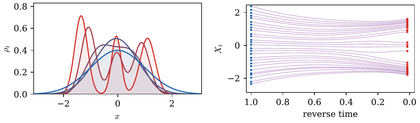

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/generative-diffusion-1d-forward-backward.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/generative-diffusion-1d-forward-backward.png")
display(Image(filename=str(_thumb)))
